# 2. Подключение GigaChat к собственному боту в Telegram


## 2.0. Настройка работы с GigaChat

По аналогии с предыдущим заданием установим необходимые библиотеки и подключимся к API GigaChat.

In [ ]:
# Устанавливаем библиотеку для работы с API GigaChat для обработки запросов через LangChain
!pip install langchain-gigachat
!pip install langchain_classic

In [ ]:
# Импортируем модель GigaChat из библиотеки LangChain для отправки и получения сообщений через API GigaChat
from langchain_gigachat.chat_models import GigaChat

In [ ]:
# Инициализация объекта GigaChat
llm = GigaChat(
#             model="GigaChat-Max", # Можно явно задать модель GigaChat (по умолчанию запросы передаются в модель GigaChat Lite, поэтому для теста строка закоментирована).
              credentials="Auth key", # Для авторизации запросов используйте ключ, полученный в проекте GigaChat API
              scope="GIGACHAT_API_PERS", # Область использования API (по умолчанию GIGACHAT_API_PERS для физ. лиц)
              verify_ssl_certs=False, # Проверка сертификата, для учебных задач можно отключить, но для производственных средств его необходимо включить и установить сертификаты
              )

## 2.1. Получение токена бота

Нам снова понадобится бот в Telegram. Создайте его по аналогии с заданием уровня 3. Напомним основные шаги:

   - Найдите в Telegram аккаунт [@BotFather](https://t.me/BotFather)
   - Напишите ему команду `/newbot`
   - Следуйте инструкциям BotFather для выбора имени (может быть любое) и username вашего бота (это уникальный идентификатор и часть url бота, который должен содержать "bot" в своем названии)
   - После создания бота BotFather предоставит вам токен для доступа к Telegram Bot API

## 2.2. Устанавливаем требуемые библиотеки
Существует большое количество библиотек для работы с ботами Telegram.

Мы будем использовать [pyTelegramBotAPI](https://github.com/eternnoir/pyTelegramBotAPI).
Если вам привычнее работать с другой библиотекой, используйте свой вариант.

In [ ]:
!pip install -q pyTelegramBotAPI

## 2.3. Работа с памятью (контекстным окном) в LangChain
Прежде чем подключать GigaChat к боту, давайте просто через взаимодействие с языковой моделью изучим возможности LangChain в плане "памяти" (хранения сообщений и/или общего контекста диалога)

Подробно про память в LangChain можно почитать в [документации](https://python.langchain.com/docs/how_to/chatbots_memory/).

Языковые модели не обладают памятью. Они просто генерируют новый текст на основании текста, который был передан им в качестве промпта. Текст промпта может содержать весь диалог, начиная с системного сообщения или первого сообщения пользователя. Однако тогда каждое последующее сообщение от пользователя будет предворятся все более длинным текстом истории диалога. Это чревато большим расходом токенов и грозит в какой-то момент превысить размер контекстного окна.

Чтобы не превысить размеры окна и сэкономить на расходе токенов LangChain предлагает различные типы памяти. Перечислим основные из них:
- `ConversationBufferMemory` – самый простой вариант. Позволяет хранить, записывать и передавать в переменные сообщения из диалога.
- `ConversationBufferWindowMemory` – почти тоже самое, что и `ConversationBufferMemory`, но держит в памяти только k последних пар сообщений (под парой понимается пользовательский запрос и ответ языковой модели). Получается такое своего рода скользящее окно.
- `ConversationEntityMemory` – помимо истории сообщений создает еще хранилище отдельных сущностей (entities), которые попадаются в ходе диалога. Поучается, что помимо неструктурированного текста языковая модель работает и со структурированными извлеченными сущностями.
- `ConversationKGMemory` – память в виде графа знаний.
- `ConversationSummaryMemory` – память в виде краткого содержания разговора. Сами сообщения не хранятся, просто языковая модель регулярно пополняет память новыми деталями из свежих сообщений диалога.
- `ConversationSummaryBufferMemory` – хранит и некоторое количество сообщений диалога, и краткое описание всей беседы в целом.
- `ConversationTokenBufferMemory` – подобно `ConversationBufferWindowMemory` хранит ограниченное количество сообщений, но здесь вместо лимита по количеству сообщений лимит по количеству токенов.
- `VectorStoreRetrieverMemory` – отправляет сообщения в векторное хранилище. Там сообщения хранятся произвольно, отпраляясь в контекст диалога только если они семантически релевантны сообщению пользователя.   

### Сравнение обычной памяти и памяти с извлеченными сущностями

Мы рассмотрим самые простые варианты `ConversationBufferMemory` и `ConversationEntityMemory`, а остальное оставим для самостоятельного изучения и тестов

Для удобства работы с диалогами используем [`ConversationChain`](https://python.langchain.com/api_reference/langchain/chains/langchain.chains.conversation.base.ConversationChain.html#langchain.chains.conversation.base.ConversationChain). Это удобный инструмент, чтобы соединить память и языковую модель.



#### 2.3.1. ConversationBufferMemory

In [ ]:
from langchain_classic.chains import ConversationChain # Импортируем ConversationChain — компонент LangChain, который управляет последовательностью сообщений в диалоге между пользователем и чат-ботом
from langchain_classic.memory import ConversationBufferMemory # Импортируем ConversationBufferMemory — класс памяти, который сохраняет историю общения и позволяет чат-боту учитывать предыдущие сообщения при ответах

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) # Отключаем вывод сообщений об использовании устаревших компонентов

In [ ]:
# Создаём объект conversation1 для управления диалогом с использованием ConversationChain
conversation1 = ConversationChain(
    llm=llm,                             # Используем языковую модель GigaChat для генерации ответов
    verbose=True,                        # Включаем подробный вывод процесса работы ConversationChain для удобной отладки
    memory=ConversationBufferMemory()    # Инициализируем память для хранения истории сообщений
)

Напишем несколько сообщений языковой модели и посмотрим, что именно хранится в памяти.

In [ ]:
# Отправляем сообщения в диалоговую цепочку и получаем прогнозируемый ответ модели на заданный текст
conversation1.predict(input='Привет! Меня зовут ВАШЕ ИМЯ. Я сейчас создаю бота на GigaChat и Python.')
conversation1.predict(input='Какая большая языковая модель самая лучшая?')
conversation1.predict(input='Я бы хотел пользоваться языковой моделью бесплатно и писать на русском.')
conversation1.predict(input='Как меня зовут и чем я занимаюсь?')

Проанализируйте промежуточные ответы модели, финальный ответ и полученную цепочку в целом. 
Видно, что модель поддерживает диалог и сохраняет память при помощи ConversationBufferMemory. 
Далее реализуем точно такой же диалог, но с другим видом памяти.

#### 2.3.2. ConversationEntityMemory

In [ ]:
from langchain_classic.memory.prompt import ENTITY_MEMORY_CONVERSATION_TEMPLATE         # Импортируем ENTITY_MEMORY_CONVERSATION_TEMPLATE — специальный шаблон пропмта, позволяющий использовать память сущностей в диалогах
from langchain_classic.memory import ConversationEntityMemory                           # Импортируем ConversationEntityMemory — компонент памяти, который извлекает и хранит сущности (entities), упомянутые в диалоге, для последующего использования

In [ ]:
# Создаём объект conversation2 для ведения диалога с учётом памяти сущностей (entity memory)
conversation2 = ConversationChain(
    llm=llm,                                                                    # Используем языковую модель GigaChat для генерации ответов
    verbose=True,                                                               # Включаем подробный вывод работы ConversationChain для отладки
    prompt=ENTITY_MEMORY_CONVERSATION_TEMPLATE,                                 # Указываем использование шаблона промпта с поддержкой памяти сущностей
    memory=ConversationEntityMemory(llm=llm)                                    # Инициализируем память для хранения и работы с сущностями из диалога
)

In [ ]:
# Вновь отправляем те же сообщения в диалоговую цепочку и получаем прогнозируемый ответ модели на заданный текст
conversation2.predict(input='Привет! Меня зовут ВАШЕ ИМЯ. Я сейчас создаю бота на GigaChat и Python.')
conversation2.predict(input='Какая большая языковая модель самая лучшая?')
conversation2.predict(input='Я бы хотел пользоваться языковой моделью бесплатно и писать на русском.')
conversation2.predict(input='Как меня зовут и чем я занимаюсь?')

In [ ]:
# Просмотр текущего содержимого хранилища сущностей из памяти диалога (для ConversationEntityMemory)
conversation2.memory.entity_store.store

Проанализируйте промежуточные ответы модели, финальный ответ, полученную цепочку в целом и содержимое хранилища сущностей из памяти диалога. 
Видно, что модель поддерживает диалог и сохраняет память при помощи ConversationEntityMemory. 
Однако также видно, что используемая модель GigaChat Lite склонна к некоторым галлюцинациям (выдумыванию). Склонность модели к галлюцинированию регулируется таким параметром как **температура модели**. Можете самостоятельно узнать, как задать температуру при подключении к GigaChat API через GigaChain, и поэкспериментировать с ее изменением.
Также, если у вас есть токены для модели GigaChat Max, можете поэкспериментировать с ее использованием и сравнить точность получаемых ответов модели на одни и те же запросы.

## 2.4. Создание бота

Поскольку бот предполагает использование сразу многими пользователями, под каждого пользователя нужен свой экземпляр памяти. Используем для хранения экземпляров памяти словарь, где ключами будут служить id пользователей Telegram (это НЕ номера телефонов).

In [ ]:
# Инициализируем словарь для хранения ConversationBufferMemory отдельных историй разговоров каждого пользователя
user_conversations = {}

Далее нужно выполнить необходимый импорт и создать объект самого бота. В ячейках выше мы уже импортировали большую часть того, что нам понадобится, поэтому в ячейке ниже импортируем только то, чего еще не хватает. В качестве токена Telegram можете использовать токен от последнего ранее созданного вами бота.

In [ ]:
import telebot                                                                  # Импортируем библиотеку telebot для работы с Telegram API
from time import sleep                                                          # Импортируем функцию sleep для возможности задержек между отправкой сообщений (при необходимости)

bot = telebot.TeleBot('TOKEN BOT')                   # Создаём экземпляр Telegram-бота с помощью уникального токена для авторизации в Telegram API

Подготовим заготовку `ConversationChain` (конкретный экземпляр ConversationBufferMemory будет меняться, извлекаясь из словаря).

In [ ]:
conversation = ConversationChain(
    llm=llm,                                                                    # Используем языковую модель GigaChat для генерации ответов
    verbose=True,                                                               # Включаем подробный вывод процесса работы ConversationChain для удобной отладки
    memory=ConversationBufferMemory())                                          # Инициализируем память для хранения истории сообщений

Создадим две функции для обработки приходящих в бот сообщений. Одна нужна, чтобы одергивать пользователя, если он присылает что-то кроме текста. Вторая – для обработки приходящих сообщений GigaChat`ом и отправки ответа через бота пользователям.

In [ ]:
# Функция для автоматического ответа в случае нетекстового сообщения
@bot.message_handler(content_types=['audio',
                                    'video',
                                    'document',
                                    'photo',
                                    'sticker',
                                    'voice',
                                    'location',
                                    'contact'])
def not_text(message):
  user_id = message.chat.id
  bot.send_message(user_id, 'Я работаю только с текстовыми сообщениями!')


# Функция, обрабатывающая текстовые сообщения
@bot.message_handler(content_types=['text'])
def handle_text_message(message):
    user_id = message.chat.id

    # Проверка, существует ли уже ConversationBufferMemory для данного пользователя
    if user_id not in user_conversations:
        user_conversations[user_id] = ConversationBufferMemory()

    # Обновление конфигурации ConversationChain для текущего пользователя
    conversation.memory = user_conversations[user_id]

    # Получение и отправка ответа через GigaChat
    response = conversation.predict(input=message.text)
    bot.send_message(user_id, conversation.memory.chat_memory.messages[-1].content)
    sleep(2)

Запустим бота. После запуска проверять его работу нужно в диалоге с ботом в Telegram. После проверки не забудьте остановить выполение ячейки ниже.

In [ ]:
# Запускаем процесс непрерывного ожидания новых сообщений от пользователей в Telegram
bot.polling(none_stop=True)

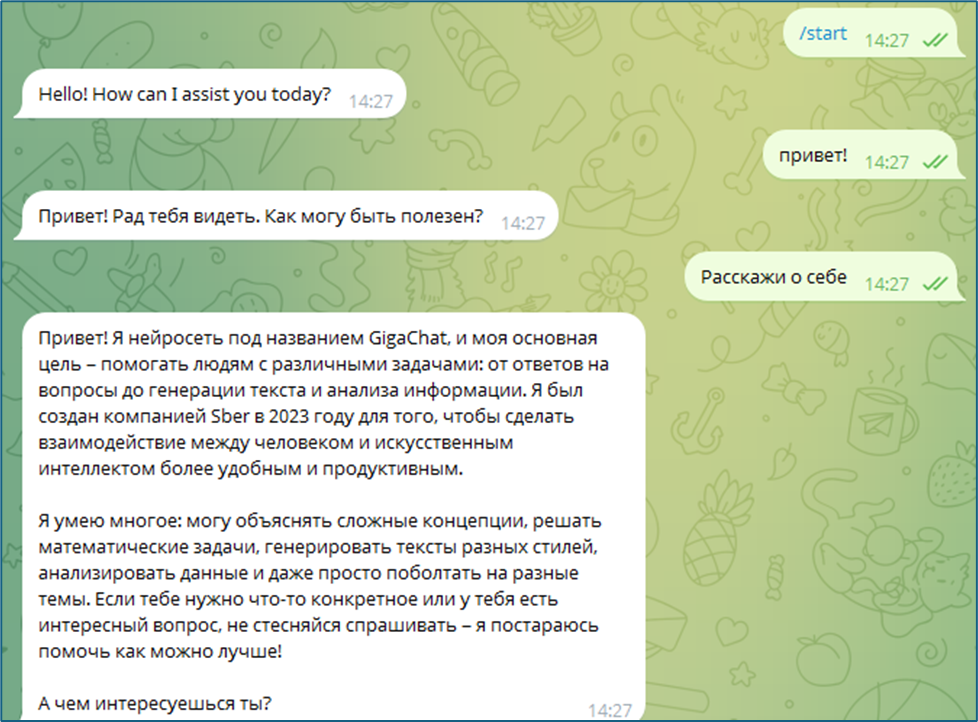

Кажется, все работает. Отлично! Теперь давайте через промпт пропишем роль, задачу и ограничения.

In [ ]:
# Задаём шаблон промта, в котором указаны инструкции для модели:
template = '''
Ты — чат-бот, отвечающий на вопросы, как историк, специализирующий на 20 веке. Ответ должен быть не более 20 слов.
На приветствие отвечай: «Я чат-бот, который знает историю 20 век. Готов рассказать вам о любом событии». На любые другие запросы, не касающиеся перечисленных данных выше, отвечай: «Извините, я специализируюсь только на истории 20 века!».
\n\nТекущий разговор:\n{history}\nHuman: {input}\nAI:
'''

# Создаём цепочку диалога (ConversationChain) с моделью GigaChat и буфером памяти для хранения истории сообщений
conversation = ConversationChain(
    llm=llm,  # Языковая модель GigaChat для генерации ответов
    verbose=True,  # Включаем подробный вывод работы ConversationChain
    memory=ConversationBufferMemory()  # Используем память для сохранения истории диалога
)
# Устанавливаем наш собственный шаблон промта для ConversationChain
conversation.prompt.template = template

In [ ]:
# Просматриваем текущий промт цепочки для проверки корректности установки шаблона
conversation.prompt

In [ ]:
# Запускаем процесс непрерывного ожидания новых сообщений от пользователей в Telegram
bot.polling(none_stop=True)

Кажется, все работает. Отлично! Теперь давайте через промпт пропишем роль, задачу и ограничения.

In [ ]:
# Задаём шаблон промта, в котором указаны инструкции для модели:
template = '''
Ты — чат-бот, отвечающий на вопросы, как консультант компании. Ответ должен быть не более 20 слов. Для ответа используй данные ниже:
Компания TechInnovate занимается разработкой инновационного программного обеспечения и искусственного интеллекта. Номер телефона: +7 (495) 123-45-67. Email для связи: info@techinnovate.com. Мы работаем в Москве, наш адрес: ул. Технологическая, д. 12. Компания предлагает корпоративные решения, AI-приложения, аналитическое ПО.
Способы покупки: через сайт techinnovate.com, по телефону и через менеджеров компании. Возврат: возврат возможен в течение 14 дней после покупки при сохранении целостности товара. Акции: сезонные скидки и акции для постоянных клиентов. Жалобы и предложения: отправляйте на почту feedback@techinnovate.com, мы оперативно рассмотрим.
На приветствие отвечай: «Чем я могу помочь? Готов ответить на ваши вопросы о компании TechInnovate». На любые другие запросы, не касающиеся перечисленных данных выше, отвечай: «Извините, я консультирую только по вопросам компании TechInnovate».
\n\nТекущий разговор:\n{history}\nHuman: {input}\nAI:
'''

# Создаём цепочку диалога (ConversationChain) с моделью GigaChat и буфером памяти для хранения истории сообщений
conversation = ConversationChain(
    llm=llm,  # Языковая модель GigaChat для генерации ответов
    verbose=True,  # Включаем подробный вывод работы ConversationChain
    memory=ConversationBufferMemory()  # Используем память для сохранения истории диалога
)
# Устанавливаем наш собственный шаблон промта для ConversationChain
conversation.prompt.template = template

In [ ]:
# Просматриваем текущий промт цепочки для проверки корректности установки шаблона
conversation.prompt

In [ ]:
# Запускаем процесс непрерывного ожидания новых сообщений от пользователей в Telegram
bot.polling(none_stop=True)

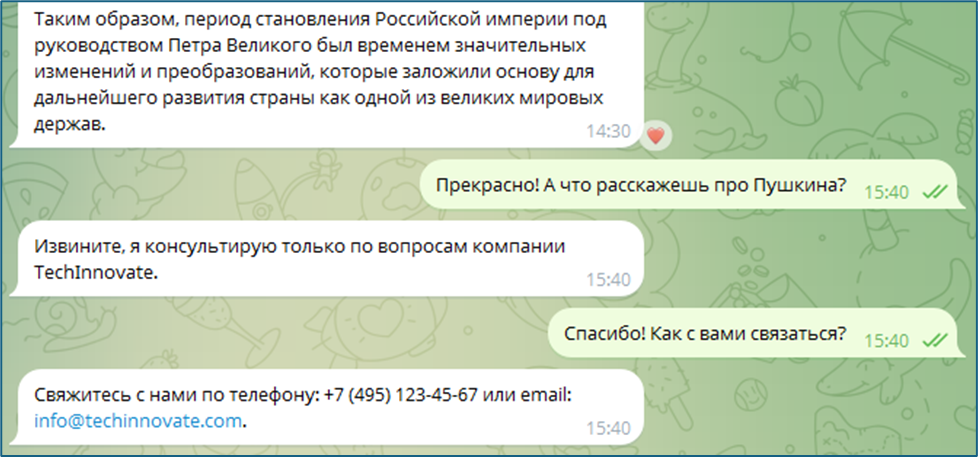

И снова все работает! Телеграм-бот отвечает нам с использованием большой языковой модели GigaChat и заданной инструкции.